# Proyecto EDA - Palmer Penguins

Plantilla guiada para alumnado junior en un contexto de trabajo real en equipo.
Este notebook no esta resuelto: debe completarse con decisiones analiticas justificadas y orientadas al cliente.

![Palmer Penguins - Ilustracion oficial](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/man/figures/lter_penguins.png)

Fuente: ilustraciones de Allison Horst para el proyecto Palmer Penguins.

## Datos del equipo

- Nombre del equipo:
- Integrantes:
- Semana de trabajo: Semana 11/12
- Fecha de entrega: martes 21.04.26

## Documento de referencia del proyecto

Antes de empezar, revisad la guia oficial del encargo:
- [Briefing del proyecto](../docs/briefing-empresa-pinguinos.md)
- [Alcance del proyecto](../docs/ALCANCE-PROYECTO-SCOPE.md)

Usad este notebook como plantilla operativa y el briefing como marco de criterios y expectativas del cliente.

## 0) Organizacion del equipo y plan de trabajo

Cada integrante debe asumir al menos una responsabilidad principal y participar en la revision final del entregable.

### Roles y responsables (asignacion obligatoria)
- Coordinacion y control de tiempos: plan semanal, seguimiento y gestion de bloqueos.
- Calidad del dato y limpieza: diagnostico de nulos/consistencia y decisiones de tratamiento.
- Analisis univariado: seleccion de variables y lectura de distribuciones.
- Analisis bivariado: analisis de relaciones y contraste de patrones.
- Visualizacion y narrativa: claridad visual y redaccion para publico cientifico no tecnico.
- Revision final y defensa oral: coherencia del notebook y preparacion de presentacion.

### Tabla de plan de trabajo inicial
Completad esta tabla en la primera sesion y actualizadla durante la semana.

| Tarea | Persona responsable | Fecha objetivo | Estado |
|---|---|---|---|
| Carga del dataset | Jose |15/04  |Finalizado |
| Diagnostico inicial | Alejandro | 16/04 |Finalizado  |
| Analisis de nulos | Eva | 17/04 | Pendiente |
| Decisiones de limpieza |Jose  | 20/04 | Pendiente |
| Analisis univariado | Arantxa | 21/04 |  Pendiente|
| Analisis bivariado | Oksana | 21/04 | Pendiente|
| Visualizaciones finales | Eva | 23/04 | Pendiente |
| Redaccion de hallazgos | Alejandro |24/04  |Pendiente |
| Conclusiones y recomendaciones | Arantxa | 24/04 | Pendiente |
| Revision final | Oksana | 26/04 | Pendiente |
| Preparacion de defensa oral | Todos | 27/04 | Pendiente |

## 0.1) Trazabilidad en Git

Mostrad el proceso de trabajo, no solo el resultado final.

Checklist minimo de trazabilidad:
- Repositorio compartido del equipo.
- README con objetivo del proyecto y nombres del equipo.
- Tablero GitHub Projects (o equivalente) con roles, tareas asignadas y tareas realizadas.
- Commits comprensibles y frecuentes durante la semana.
- Evidencia de seguimiento (no un unico commit final).

Estructura minima recomendada del repositorio:
- /data/penguins.csv
- notebook del proyecto
- README.md
- tablero GitHub Projects

Nota: un entregable sin trazabilidad de proceso no se considera un trabajo profesional completo.

## Preparacion del entorno

Objetivo: cargar librerias y dataset para iniciar el analisis.

### Recursos de apoyo rapido

Dataset del proyecto (descarga directa):

- CSV oficial Palmer Penguins: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv
- Guardadlo como: `./data/penguins.csv`

Recursos tecnicos recomendados para avanzar con autonomia:

- Carga de CSV con pandas: [pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
- Gestion de nulos en pandas: [Missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
- Histograma en seaborn: [sns.histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html)
- Scatterplot en seaborn: [sns.scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)
- Boxplot en seaborn: [sns.boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)
- Subplots en matplotlib: [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)

Recursos de trabajo en equipo:

- Guia basica de Markdown: [Markdown Guide](https://www.markdownguide.org/basic-syntax/)
- Buenas practicas de commits: [GitHub - Commit best practices](https://github.blog/developer-skills/github/write-better-commits-build-better-projects/)
- Tablero opcional de tareas: [GitHub Projects](https://docs.github.com/es/issues/planning-and-tracking-with-projects/learning-about-projects/about-projects)

Recomendacion practica: si usais GitHub Projects, mantened columnas simples (Pendiente, En curso, Revisado, Hecho) y actualizad el tablero en cada sesion.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def cargar_dataset_penguins(mostrar_head=True, mode="notebook"):
    

    # Configuración visual (se ejecuta una sola vez normalmente)
    sns.set_theme(style='whitegrid')
    plt.rcParams['figure.figsize'] = (10, 5)

    # Carga del dataset
    try:
        from palmerpenguins import load_penguins
        df = load_penguins()
    except ImportError:
        raise ImportError("Instala palmerpenguins: pip install palmerpenguins")

    # Mostrar datos según entorno
    if mostrar_head:
        if mode == "streamlit":
            import streamlit as st
            st.subheader("Vista previa del dataset")
            st.dataframe(df.head())
        elif mode == "notebook":
            print("Vista previa del dataset:")
            print(df.head())
        elif mode == "none":
            pass
        else:
            raise ValueError("mode debe ser 'notebook', 'streamlit' o 'none'")

    return df
df = cargar_dataset_penguins(mode="notebook")

## 1) Diagnostico inicial

Objetivo: entender estructura y estado inicial del dataset.

Revisad como minimo:
1. Dimensiones
2. Tipos de datos
3. Nulos por columna
4. Duplicados

In [ ]:
import pandas as pd
from io import StringIO

def inspeccionar_dataframe(df, mode="notebook", devolver_resultados=True):
 

    # Dimensiones
    dimensiones = df.shape

    # Info (convertimos a string porque df.info() no devuelve directamente)
    buffer = StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()

    # Tipos de datos
    dtypes = df.dtypes

    # Nulos
    nulos = df.isna().sum()

    # Duplicados
    duplicados = df.duplicated().sum()

    # Mostrar según entorno
    if mode == "streamlit":
        import streamlit as st

        st.subheader("📊 Información general del dataset")

        st.write(f"**Dimensiones:** {dimensiones}")

        st.write("**Info general:**")
        st.text(info_str)

        st.write("**Tipos de datos:**")
        st.dataframe(dtypes.to_frame(name="tipo"))

        st.write("**Nulos por columna:**")
        st.dataframe(nulos.to_frame(name="nulos"))

        st.write(f"**Duplicados:** {duplicados}")

    elif mode == "notebook":
        print("Dimensiones:", dimensiones)
        print("\nInfo general:")
        print(info_str)
        print("\nTipos de datos:")
        print(dtypes)
        print("\nNulos por columna:")
        print(nulos)
        print("\nDuplicados:", duplicados)

    elif mode == "none":
        pass

    else:
        raise ValueError("mode debe ser 'notebook', 'streamlit' o 'none'")

    if devolver_resultados:
        return {
            "dimensiones": dimensiones,
            "info": info_str,
            "dtypes": dtypes,
            "nulos": nulos,
            "duplicados": duplicados
        }

inspeccionar_dataframe(df, mode="notebook")

### Interpretacion guiada

Responded brevemente:
1. La variable body_mass_g presenta asimetría positiva (skewness = X), lo que indica que la distribución no es normal y la media no es el estadístico más representativo. Se recomienda usar la mediana o aplicar transformación logarítmica antes de modelar.
2. ¿Qué problema de calidad es más relevante?
Los 11 nulos en Sex, porque es una variable categórica clave para análisis biológico y no se puede imputar matemáticamente como las numéricas — requiere criterio de dominio o descarte.
3. ¿Por qué le importa al cliente?
Si el cliente quiere analizar diferencias físicas entre machos y hembras (algo típico en estudios de fauna), esos 11 registros quedan fuera o introducen sesgo, afectando directamente la fiabilidad de sus conclusiones.

### ⚠️ NOTA IMPORTANTE: Alcance del análisis

Durante el diagnóstico, es normal que encuentren desequilibrios:
- "¿Por qué hay pocas observaciones de especie X en isla Y?"
- "¿Cuál es el hábitat natural de cada especie?"

**ESTO NO ES VUESTRO ANÁLISIS.**

Vuestro trabajo es:
✅ Describir QUÉ muestra el dataset (patrones, distribuciones, desequilibrios)  
✅ Documentar estos desequilibrios como SESGO DE MUESTREO (en limitaciones)  
✅ Recomendar mejoras futuras  

**NO es vuestro trabajo:**
❌ Investigar POR QUÉ (biogeografía, ecología, evolución)  
❌ Especular sobre causas sin datos externos  

**Regla de oro:** Si no puedes responder SOLO mirando el CSV, está fuera de scope.

👉 Leed `ALCANCE-PROYECTO-SCOPE.md` antes de invertir tiempo en preguntas especulativas.

## 2) Limpieza y decisiones de calidad de datos

Objetivo: aplicar una limpieza con criterio y conectarla con el analisis posterior.

Instruccion clave:
No hagais limpieza automatica sin justificar. Cada decision debe explicar su impacto esperado en la lectura de resultados.

Recomendacion de trabajo:
1. Detectad el problema de calidad.
2. Elegid una decision de tratamiento.
3. Justificad por que esa decision es razonable.
4. Verificad su efecto sobre el dataset y sobre el analisis.

In [ ]:
import pandas as pd

def limpiar_dataframe_penguins(df, mode="notebook", devolver_df=True):
    

    df_limpio = df.copy()

    filas_originales = len(df_limpio)

    # 1. Eliminar duplicados
    df_limpio = df_limpio.drop_duplicates()

    # 2. Eliminar nulos en variables clave
    columnas_clave = [
        'bill_length_mm',
        'bill_depth_mm',
        'flipper_length_mm',
        'body_mass_g'
    ]

    df_limpio = df_limpio.dropna(subset=columnas_clave)

    # 3. Imputar variable categórica
    if 'sex' in df_limpio.columns:
        df_limpio['sex'] = df_limpio['sex'].fillna('DESCONOCIDO')

    filas_finales = len(df_limpio)
    filas_eliminadas = filas_originales - filas_finales

    nulos_finales = df_limpio.isna().sum()

    # Mostrar resultados según entorno
    if mode == "streamlit":
        import streamlit as st

        st.subheader("🧹 Limpieza de datos")

        st.write(f"**Filas originales:** {filas_originales}")
        st.write(f"**Filas tras limpieza:** {filas_finales}")
        st.write(f"**Filas eliminadas:** {filas_eliminadas}")

        st.write("**Nulos tras limpieza:**")
        st.dataframe(nulos_finales.to_frame(name="nulos"))

        st.dataframe(df_limpio.head())

    elif mode == "notebook":
        print("Filas originales:", filas_originales)
        print("Filas tras limpieza:", filas_finales)
        print("Filas eliminadas:", filas_eliminadas)

        print("\nNulos tras limpieza:")
        print(nulos_finales)

        print("\nPreview:")
        print(df_limpio.head())

    elif mode == "none":
        pass

    else:
        raise ValueError("mode debe ser 'notebook', 'streamlit' o 'none'")

    if devolver_df:
        return df_limpio
    
df_limpio = limpiar_dataframe_penguins(df, mode="notebook")

### Tabla de decisiones de calidad del dato


| Problema detectado | Columna afectada | Decision tomada | Justificacion | Impacto esperado |
|---|---|---|---|---|
|Duplicados|Ninguna|Ninguna|Revisión para evitar problemas |Ninguno|
|Nulos|Medidas corporales|Eliminación|Al ser menos de un 5% eliminamos para evitar problemas|Evitar distorsión de valores|
|Nulos|Sexo|Modificar valor nulo por desconocido|Al ser mayor cantidad decidimos estudiarlos de esta manera para evitar perder mas datos|Evitar distorsión de valores|


### Interpretacion guiada

### 1. ¿Qué decisión de limpieza tuvo mayor impacto en el dataset?

La eliminación de filas con valores nulos en variables numéricas clave (como bill_length_mm, bill_depth_mm, flipper_length_mm y body_mass_g) ha sido la decisión con mayor impacto, ya que ha reducido de forma notable el número de registros disponibles para el análisis.

Esto se debe a que estas variables son fundamentales para el estudio morfológico de los pingüinos, y cualquier fila con datos incompletos en ellas pierde valor analítico.

---

### 2. ¿Qué riesgo se evita con esa decisión?

Al eliminar estas filas, se evita el riesgo de:
Obtener resultados distorsionados en cálculos estadísticos (media, desviación, correlaciones),
Generar gráficos incompletos o difíciles de interpretar,
Introducir ruido o inconsistencias en el análisis,

En resumen, se mejora la fiabilidad del análisis al trabajar únicamente con datos completos en variables clave.

---

### 3. ¿Qué posible efecto secundario puede introducir?

La principal consecuencia negativa es la pérdida de información, ya que se descartan observaciones que podrían ser útiles en otros análisis (por ejemplo, categóricos).

Además, si los valores nulos no están distribuidos de forma aleatoria, esta eliminación podría introducir sesgo en el dataset final, afectando la representatividad de los resultados.

Por ello, esta decisión implica un equilibrio entre calidad de datos y cantidad de información disponible.

## 3) Analisis univariado

Objetivo: describir distribuciones y patrones principales.

Requisitos minimos:
1. Al menos 3 variables numericas
2. Al menos 1 variable categorica
3. Graficos titulados y legibles

### Variables numéricas

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def analizar_variables_numericas_basico(
    df_limpio,
    variables_numericas=None,
    mode="notebook",
    devolver_resultados=True
):
   

    if variables_numericas is None:
        variables_numericas = [
            'bill_length_mm',
            'bill_depth_mm',
            'body_mass_g',
            'flipper_length_mm'
        ]

    resultados = {}

    for col in variables_numericas:

        if col not in df_limpio.columns:
            continue

        serie = df_limpio[col].dropna()

        estadisticos = serie.describe()
        skew_val = serie.skew()

        # Crear figura (IMPORTANTE: no usar plt.figure suelto)
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.histplot(serie, kde=True, ax=ax)

        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')

        fig.tight_layout()

        # Mostrar según entorno
        if mode == "streamlit":
            import streamlit as st

            st.subheader(col.upper())
            st.write("Estadísticos:")
            st.dataframe(estadisticos.to_frame(name="valor"))
            st.write(f"Skew: {skew_val:.4f}")
            st.pyplot(fig)

        elif mode == "notebook":
            print(f"\n--- {col.upper()} ---")
            print("Estadísticos:")
            print(estadisticos)
            print("\nSkew (asimetría):", skew_val)
            plt.show()

        elif mode == "none":
            pass

        else:
            raise ValueError("mode inválido")

        resultados[col] = {
            "estadisticos": estadisticos,
            "skew": skew_val,
            "fig": fig
        }

        # CLAVE: evitar duplicados
        plt.close(fig)

    if devolver_resultados:
        return resultados
    
analizar_variables_numericas_basico(df_limpio, mode="notebook")

### Gráfico: Distribución de bill_length_mm

**1. ¿Qué muestra este gráfico?**  
Representa la distribución de la longitud del pico en milímetros.

**2. ¿Qué patrón relevante aparece?**  
Se observa variabilidad en los valores, lo que sugiere diferencias morfológicas entre individuos.

**3. ¿Por qué le importa al cliente?**  
Esta variable puede ser clave para diferenciar especies o analizar adaptaciones biológicas.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
No se puede determinar a qué grupo pertenece cada valor sin relacionarlo con variables categóricas.

---

### Gráfico: Distribución de bill_depth_mm

**1. ¿Qué muestra este gráfico?**  
Muestra la distribución de la altura del pico de los pingüinos, indicando cómo se reparten los valores en el dataset.

**2. ¿Qué patrón relevante aparece?**  
Se observa variabilidad en la altura del pico, con una posible concentración de valores en determinados rangos, lo que sugiere diferencias morfológicas entre individuos.

**3. ¿Por qué le importa al cliente?**  
La altura del pico es una característica relevante para diferenciar especies o estudiar adaptaciones al entorno, por lo que puede aportar valor en la segmentación o clasificación de los individuos.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
Este análisis no permite identificar qué grupos (especies o sexos) presentan mayores o menores valores, ya que no se han cruzado variables. Además, la interpretación puede verse afectada por el tamaño de la muestra o la presencia de posibles sesgos en los datos.

---

### Gráfico: Distribución de body_mass_g

**1. ¿Qué muestra este gráfico?**  
Muestra la distribución de la masa corporal de los pingüinos, indicando la frecuencia de valores en distintos rangos.

**2. ¿Qué patrón relevante aparece?**  
Se observa una dispersión considerable y posibles agrupaciones que sugieren diferencias entre individuos o especies.

**3. ¿Por qué le importa al cliente?**  
Permite identificar diferencias físicas relevantes que pueden estar asociadas a especies, hábitats o comportamientos.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
No se puede identificar la causa de la variabilidad sin cruzar esta variable con otras (como especie o isla).

---

### Gráfico: Distribución de flipper_length_mm

**1. ¿Qué muestra este gráfico?**  
Muestra la distribución de la longitud de las aletas de los pingüinos, indicando cómo se reparten los valores en el dataset.

**2. ¿Qué patrón relevante aparece?**  
Se observa una variabilidad clara en la longitud de las aletas, con posibles concentraciones en determinados rangos, lo que sugiere diferencias de tamaño entre individuos o grupos.

**3. ¿Por qué le importa al cliente?**  
La longitud de la aleta es un buen indicador del tamaño corporal del pingüino y puede ayudar a diferenciar especies o analizar características físicas relevantes, siendo útil para segmentación o clasificación.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
Este análisis no permite identificar qué grupos específicos presentan mayores o menores longitudes de aleta, ya que no se han cruzado variables. Además, la interpretación puede verse limitada por el tamaño de la muestra o posibles sesgos en los datos.

### Variables categoricas

In [ ]:
import matplotlib.pyplot as plt

def analizar_variables_categoricas(
    df_limpio,
    variables_categoricas=None,
    mode="notebook",
    devolver_resultados=True
):
    

    # Detectar automáticamente si no se pasan
    if variables_categoricas is None:
        variables_categoricas = df_limpio.select_dtypes(include='object').columns

    resultados = {}

    for col in variables_categoricas:

        if col not in df_limpio.columns:
            continue

        # Frecuencias
        tabla = df_limpio[col].value_counts()
        proporciones = df[col].value_counts(normalize=True)

        # Gráfico
        fig, ax = plt.subplots(figsize=(6, 4))
        tabla.plot(kind='bar', ax=ax)

        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.tick_params(axis='x', rotation=0)

        fig.tight_layout()

        # Mostrar según entorno
        if mode == "streamlit":
            import streamlit as st

            st.subheader(col.upper())

            st.write("Frecuencias:")
            st.dataframe(tabla.to_frame(name="frecuencia"))

            st.write("Proporciones:")
            st.dataframe(proporciones.to_frame(name="proporción"))

            st.pyplot(fig)

        elif mode == "notebook":
            print(f"\n--- {col.upper()} ---")

            print("Frecuencias:")
            print(tabla)

            print("\nProporciones:")
            print(proporciones)

            plt.show()

        elif mode == "none":
            pass

        else:
            raise ValueError("mode inválido")

        resultados[col] = {
            "frecuencias": tabla,
            "proporciones": proporciones,
            "fig": fig
        }

        # CLAVE: evitar duplicados
        plt.close(fig)

    if devolver_resultados:
        return resultados
    
analizar_variables_categoricas(df_limpio, mode="notebook")

### Gráfico: Distribución por especies

**1. ¿Qué muestra este gráfico?**  
Muestra la frecuencia de cada especie de pingüino en el dataset, indicando cuántos individuos pertenecen a cada grupo.

**2. ¿Qué patrón relevante aparece?**  
Se observa que las especies no están distribuidas de forma uniforme, lo que indica un posible desbalance entre grupos dentro del dataset.

**3. ¿Por qué le importa al cliente?**  
La distribución de especies es clave para entender la composición del dataset y puede influir en los análisis posteriores, especialmente en comparaciones entre grupos o modelos de clasificación.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
No se puede determinar si esta distribución refleja la realidad o es consecuencia del proceso de muestreo. Además, no permite analizar diferencias entre especies sin cruzar esta variable con variables numéricas.

---

### Gráfico: Distribución por isla

**1. ¿Qué muestra este gráfico?**  
Muestra la frecuencia de pingüinos en cada isla, indicando cómo se distribuyen las observaciones según su ubicación geográfica.

**2. ¿Qué patrón relevante aparece?**  
Se observa que las islas no están representadas de forma uniforme, lo que sugiere que algunas tienen mayor presencia de individuos que otras.

**3. ¿Por qué le importa al cliente?**  
La isla puede influir en las características de los pingüinos debido a factores ambientales como el clima o la disponibilidad de alimento. Por ello, es una variable clave para entender posibles diferencias entre grupos.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
No se puede determinar si las diferencias observadas se deben a factores reales o a cómo se recogieron los datos. Además, este análisis no permite identificar cómo varían las características físicas entre islas sin cruzar variables.

---

### Gráfico: Distribución por sexo

**1. ¿Qué muestra este gráfico?**  
Muestra la frecuencia de cada categoría de la variable `sex` en el dataset, incluyendo posibles valores imputados como “desconocido”.

**2. ¿Qué patrón relevante aparece?**  
Se observa la distribución entre machos y hembras, así como la posible presencia de valores desconocidos, lo que puede indicar datos incompletos en el dataset original.

**3. ¿Por qué le importa al cliente?**  
El sexo de los individuos puede influir en características físicas como el tamaño o la masa corporal, por lo que es una variable relevante para segmentar y analizar diferencias dentro de la población.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
La presencia de valores desconocidos puede reducir la precisión del análisis. Además, esta variable por sí sola no permite identificar diferencias físicas sin cruzarse con variables numéricas.

## 4) Analisis bivariado

Objetivo: explorar relaciones entre variables con sentido para el cliente.

Requisitos minimos:
1. Al menos 3 relaciones relevantes
2. Incluir al menos una relacion numerica-numerica
3. Incluir al menos una relacion categorica-numerica
4. Justificar por que se eligio cada relacion

### Apoyo visual oficial para variables morfologicas

![Referencia de medidas del pico](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/man/figures/culmen_depth.png)

Usad esta referencia para no confundir las medidas al interpretar relaciones entre variables.

### Relacion numerica-numerica 
(Relacion entre longitud y altura del pico)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_scatter_penguins(
    df_limpio,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    mode="notebook",
    devolver_fig=False
):

    # Crear figura correctamente (evita duplicados)
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.scatterplot(
        data=df_limpio,
        x=x,
        y=y,
        hue=hue,
        ax=ax
    )

    ax.set_title(f'Relación entre {x} y {y}')
    fig.tight_layout()

    # Mostrar según entorno
    if mode == "streamlit":
        import streamlit as st
        st.pyplot(fig)

    elif mode == "notebook":
        from IPython.display import display
        display(fig)

    elif mode == "none":
        pass

    else:
        raise ValueError("mode inválido")

    # Cerrar figura para evitar duplicados
    plt.close(fig)

    if devolver_fig:
        return fig

plot_scatter_penguins(df_limpio, mode="notebook", devolver_fig=False)

**1. Evidencia**   
Tres nubes de puntos bastante separadas, una por especie.   
**2. Interpretación**   
La morfología del pico es suficientemente distinta entre especies como para separarlas visualmente sin necesidad de otras variables.   
**3. Implicación para el cliente**   
Solo con estas dos medidas un modelo de clasificación podría identificar la especie con buena precisión.   
**4. Limitación**   
Existe algo de solapamiento entre Adelie y Chinstrap, lo que generaría casos ambiguos en un clasificador real.   

### Relacion categorica-numerica 
(Masa corporal por especie)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_boxplot_penguins(
    df_limpio,
    x='species',
    y='body_mass_g',
    mode="notebook",
    devolver_fig=False
):

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.boxplot(
        data=df_limpio,
        x=x,
        y=y,
        ax=ax
    )

    ax.set_title(f'{y} por {x}')
    fig.tight_layout()

    # Mostrar según entorno
    if mode == "streamlit":
        import streamlit as st
        st.pyplot(fig)

    elif mode == "notebook":
        from IPython.display import display
        display(fig)

    elif mode == "none":
        pass

    else:
        raise ValueError("mode inválido")

    # evitar duplicados SIEMPRE
    plt.close(fig)

    if devolver_fig:
        return fig
    
plot_boxplot_penguins(df_limpio, mode="notebook")

**1. Evidencia**   
Gentoo tiene una masa notablemente mayor que Adelie y Chinstrap, cuyas distribuciones son similares y se solapan.   
**2. Interpretación**   
El tamaño corporal es un rasgo diferenciador claro entre Gentoo y las otras dos especies, pero no distingue bien entre Adelie y Chinstrap.   
**3. Implicación para el cliente**   
La masa corporal por sí sola solo es útil para identificar Gentoo. Para distinguir Adelie de Chinstrap se necesitan otras variables como las dimensiones del pico.   
**4. Limitación**   
Los outliers de Chinstrap visibles en el boxplot podrían distorsionar la media e influir en modelos predictivos si no se tratan previamente. Como podemos observar en el gráfico, hay dos outliers en la especie Chinstrap, que, revisando los datos originales del csv, vemos que el outlier superior corresponde a un macho, lo que encaja con la diferencia ya que los machos de esta especie son mucho más grandes que las hembras, y el outlier inferior corresponde a una hembra, que puede ser una hembra joven o con algún tipo de problema de peso, pero es un peso posible en hembras de esta especie.

### Heatmap de correlaciones

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def correlacion_heatmap(
    df_limpio,
    mostrar_tabla=True,
    mode="notebook",
    devolver_fig=False
):
    
    # Calcular correlación
    
    corr = df_limpio.drop('year', axis=1).select_dtypes(include='number').corr()
    # Crear figura
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.heatmap(
        corr,
        cmap='coolwarm',
        annot=True,
        ax=ax
    )

    ax.set_title("Matriz de correlación")
    fig.tight_layout()

    # Mostrar según entorno
    if mode == "streamlit":
        import streamlit as st

        if mostrar_tabla:
            st.write("Matriz de correlación:")
            st.dataframe(corr)

        st.pyplot(fig)

    elif mode == "notebook":
        from IPython.display import display

        if mostrar_tabla:
            print("Matriz de correlación:")
            display(corr)

        display(fig)

    elif mode == "none":
        pass

    else:
        raise ValueError("mode inválido")

    # evitar duplicados
    plt.close(fig)

    if devolver_fig:
        return fig

correlacion_heatmap(df_limpio, mode="notebook")

**1. Evidencia**   
flipper_length_mm y body_mass_g muestran la correlación más alta (≈0.87). Las correlaciones con bill_depth_mm son negativas para el resto de variables numéricas.   
**2. Interpretación**   
Los pingüinos más grandes tienen aletas más largas — las variables de tamaño corporal van de la mano. La profundidad del pico se comporta de forma inversa al resto, posiblemente porque varía más entre especies que dentro de ellas.   
**3. Implicación para el cliente**   
Para un modelo predictivo, flipper_length_mm y body_mass_g son variables muy redundantes.     
**4. Limitación**   
Pearson solo detecta relaciones lineales. Si alguna relación es curvilínea, el heatmap la subestimará. 

### Barras agrupadas: especies por isla y sexo

In [ ]:
import matplotlib.pyplot as plt

def plot_conteo_penguins(
    df_limpio,
    group_cols=['island', 'species', 'sex'],
    mode="notebook",
    devolver_fig=False,
    mostrar_tabla=False
):

    # Agrupación
    conteo = (
        df_limpio.groupby(group_cols)
        .size()
        .unstack(fill_value=0)
    )

    # Crear figura
    fig, ax = plt.subplots(figsize=(10, 6))

    conteo.plot(kind='bar', ax=ax)

    ax.set_title('Especies de Pingüinos por Isla y Sexo')
    ax.set_xlabel('Isla y Especie')
    ax.set_ylabel('Cantidad de Pingüinos')

    plt.xticks(rotation=45, ha='right')
    ax.legend(title='Sexo')

    fig.tight_layout()

    # Mostrar según entorno
    if mode == "streamlit":
        import streamlit as st

        if mostrar_tabla:
            st.write("Tabla de conteo:")
            st.dataframe(conteo)

        st.pyplot(fig)

    elif mode == "notebook":
        from IPython.display import display

        if mostrar_tabla:
            print("Tabla de conteo:")
            display(conteo)

        display(fig)

    elif mode == "none":
        pass

    else:
        raise ValueError("mode inválido")

    # evitar duplicados
    plt.close(fig)

    if devolver_fig:
        return fig
    
plot_conteo_penguins(df_limpio, mode="notebook")

**1. Evidencia**   
Biscoe alberga principalmente Gentoo, Torgersen solo Adelie, y Dream tiene Adelie y Chinstrap. La distribución entre machos y hembras es equilibrada en todas las combinaciones.   
**2. Interpretación**   
Cada especie tiene una preferencia de hábitat clara — no conviven todas en la misma isla, lo que sugiere nichos ecológicos diferenciados. La población está bien balanceada por sexo en todas las combinaciones isla-especie, lo que sugiere una muestra representativa. Gentoo domina en Biscoe y es la especie con mayor presencia total.   
**3. Implicación para el cliente**   
El equilibrio de sexos es una buena señal para análisis posteriores — no hay sesgo de muestreo por sexo dentro de cada grupo.   
**4. Limitación**   
Los individuos "DESCONOCIDO" son pocos pero presentes — si su sexo real no es aleatorio (por ejemplo, si son más difíciles de sexar en una especie concreta), podrían introducir un pequeño sesgo en comparaciones por sexo.

### Boxplot: longitutd del pico solo de la especie Adelie dependiendo de la isla

In [ ]:
import matplotlib.pyplot as plt

def plot_boxplot_adelie_island(
    df_limpio,
    especie='Adelie',
    variable='bill_length_mm',
    grupo='island',
    colores=None,
    mode="notebook",
    devolver_fig=False
):
    
    # Filtrar especie
    df_filtrado = df_limpio[df_limpio['species'] == especie]

    if df_filtrado.empty:
        raise ValueError(f"No hay datos para la especie: {especie}")

    # Colores por defecto
    if colores is None:
        colores = ['#378ADD', '#E24B4A', '#1D9E75']

    # Crear figura
    fig, ax = plt.subplots(figsize=(10, 6))

    bp = df_filtrado.boxplot(
        column=variable,
        by=grupo,
        patch_artist=True,
        return_type='dict',
        ax=ax
    )

    # Aplicar colores
    boxes = bp[variable]['boxes']
    for patch, color in zip(boxes, colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Estilo medianas
    for median in bp[variable]['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    # Títulos
    ax.set_title(f'{variable} de {especie} por {grupo}')
    plt.suptitle('')  # quitar título automático

    ax.set_xlabel(grupo)
    ax.set_ylabel(variable)

    fig.tight_layout()

    # Mostrar según entorno
    if mode == "streamlit":
        import streamlit as st
        st.pyplot(fig)

    elif mode == "notebook":
        from IPython.display import display
        display(fig)

    elif mode == "none":
        pass

    else:
        raise ValueError("mode inválido")

    # evitar duplicados
    plt.close(fig)

    if devolver_fig:
        return fig
    
plot_boxplot_adelie_island(df_limpio, mode="notebook")

**1. Evidencia**   
Biscoe y Torgersen tienen medianas ligeramente más altas (~39mm) que Dream (~38.5mm). Dream muestra mayor dispersión hacia valores bajos y Torgersen tiene el rango intercuartílico más amplio. Biscoe tiene un outlier en ~46mm.   
**2. Interpretación**   
Aunque las diferencias son pequeñas, existe cierta variación en la longitud del pico según la isla, lo que podría indicar ligeras adaptaciones locales dentro de la misma especie.   
**3. Implicación para el cliente**   
La isla aporta algo de información sobre la longitud del pico en Adelie, aunque el efecto es modesto y probablemente no suficiente como variable predictora por sí sola.   
**4. Limitación**   
En resumen, el gráfico sugiere diferencias, pero no permite concluir causalidad sin controlar esas variables

### Scatterplots múltiples: masa corporal vs resto de variables

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_multivariado_penguins(
    df_limpio,
    x_var='body_mass_g',
    y_vars=None,
    y_labels=None,
    hue='species',
    mode="notebook",
    devolver_fig=False
):


    if y_vars is None:
        y_vars = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']

    if y_labels is None:
        y_labels = y_vars

    x_label = x_var

    # Crear figura
    fig, ax = plt.subplots(
        nrows=1,
        ncols=len(y_vars),
        figsize=(5 * len(y_vars), 4),
        sharex=True
    )

    # Si solo hay una variable (evitar error)
    if len(y_vars) == 1:
        ax = [ax]

    # Crear gráficos
    for i, (y, y_label) in enumerate(zip(y_vars, y_labels)):

        sns.scatterplot(
            data=df_limpio,
            x=x_var,
            y=y,
            hue=hue,
            ax=ax[i]
        )

        ax[i].set_xlabel(x_label)
        ax[i].set_ylabel(y_label)

        # Quitar leyenda en todos menos el último
        if i < len(y_vars) - 1:
            ax[i].get_legend().remove()

    fig.suptitle(f'Análisis Multivariado de {x_label}')
    fig.tight_layout()

    # Mostrar según entorno
    if mode == "streamlit":
        import streamlit as st
        st.pyplot(fig)

    elif mode == "notebook":
        from IPython.display import display
        display(fig)

    elif mode == "none":
        pass

    else:
        raise ValueError("mode inválido")

    # evitar duplicados
    plt.close(fig)

    if devolver_fig:
        return fig
    
plot_multivariado_penguins(
    df_limpio,
    x_var='body_mass_g',
    y_vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm'],
    y_labels=[
        'Longitud del pico [mm]',
        'Altura del pico [mm]',
        'Longitud de la aleta [mm]'
    ],
    mode="notebook"
)

**1. Evidencia**   
Gentoo destaca en masa corporal, longitud de aleta y longitud de pico. Adelie y Chinstrap se solapan en masa pero se separan en altura de pico.   
**2. Interpretación**   
La masa corporal correlaciona positivamente con la longitud de aleta y del pico, especialmente en Gentoo. La altura del pico es la variable que mejor separa Adelie de Chinstrap a igual masa.   
**3. Implicación para el cliente**   
Combinar masa corporal con longitud de aleta es muy efectivo para identificar Gentoo. Para distinguir las otras dos especies, hay que añadir la altura del pico.   
**4. Limitación**   
El solapamiento entre Adelie y Chinstrap en los tres gráficos indica que ninguna variable por sí sola es suficiente — un clasificador necesitaría combinar varias.

## 5) Visualizacion final

Objetivo: sintetizar el analisis en un panel claro para un publico cientifico no tecnico.

Instruccion:
Seleccionad 4 visualizaciones realmente utiles para responder al cliente.
No se trata de mostrar todo, sino de priorizar evidencias claras y accionables.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_dashboard_penguins(
    df_limpio,
    mode="notebook",
    devolver_fig=False
):

    # Matriz de correlación
    corr = df_limpio.drop('year', axis=1).select_dtypes(include='number').corr()

    # Crear figura
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Heatmap
    sns.heatmap(
        corr,
        cmap='coolwarm',
        annot=True,
        ax=axes[0, 0]
    )
    axes[0, 0].set_title('Matriz de correlación')

    # 2. Boxplot
    sns.boxplot(
        data=df_limpio,
        x='species',
        y='body_mass_g',
        ax=axes[0, 1]
    )
    axes[0, 1].set_title('Masa corporal por especie')

    # 3. Scatterplot
    sns.scatterplot(
        data=df_limpio,
        x='bill_length_mm',
        y='bill_depth_mm',
        hue='species',
        ax=axes[1, 0],
        legend=False
    )
    axes[1, 0].set_title('Longitud vs profundidad del pico')

    # 4. Conteo agrupado
    conteo = (
        df_limpio.groupby(['island', 'species', 'sex'])
        .size()
        .unstack(fill_value=0)
    )

    conteo.plot(kind='bar', ax=axes[1, 1])
    axes[1, 1].set_title('Especies por isla y sexo')

    # Ajustes generales
    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45)

    fig.tight_layout()

    # Mostrar según entorno
    if mode == "streamlit":
        import streamlit as st
        st.pyplot(fig)

    elif mode == "notebook":
        from IPython.display import display
        display(fig)

    elif mode == "none":
        pass

    else:
        raise ValueError("mode inválido")

    # evitar duplicados
    plt.close(fig)

    if devolver_fig:
        return fig
    
plot_dashboard_penguins(df_limpio, mode="notebook")

### Interpretacion guiada del panel final

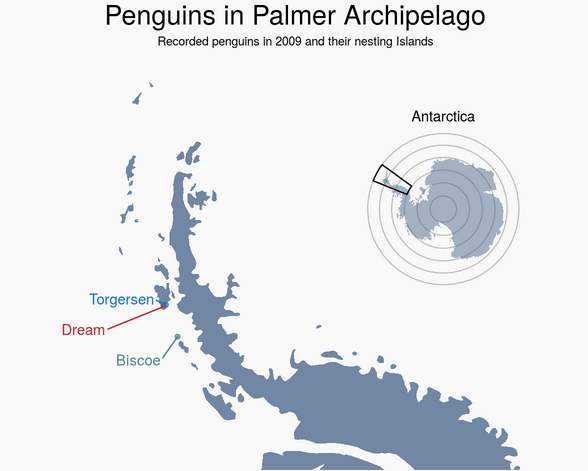

### 🧠 1. Mensaje principal para el cliente

El dataset muestra que:

Las especies de pingüinos presentan diferencias morfológicas claras y están asociadas a entornos específicos (islas), lo que sugiere que cualquier estrategia de conservación o repoblación debe considerar tanto características físicas como el hábitat.

No todas las especies pueden sobrevivir en cualquier isla.   
Hay adaptación al entorno.   
Hay diferencias biológicas relevantes entre especies.   

### 📊 2. ¿Qué gráfico respalda mejor este mensaje?

🔥 **Principal:**  *Distribución por isla, especie y sexo (abajo derecha)*

**Por qué:** 
Muestra que no todas las especies están en todas las islas.   
Evidencia segregación geográfica.   
Es clave para decisiones de repoblación.   

🧬 **Apoyo fuerte:** *Boxplot de masa corporal por especie (arriba derecha)*   

Gentoo tiene mayor masa → distinta fisiología.   
Diferencias claras entre especies.   

Refuerza que no son intercambiables biológicamente.

📈 **Apoyo técnico:** *Correlación (arriba izquierda)*

Relación fuerte: flipper_length_mm ↔ body_mass_g (0.87).   
Indica coherencia biológica.   

Sirve para validar que los datos tienen sentido, pero no es el más útil para decisiones.

🔍 **Apoyo visual:** *Scatter pico (abajo izquierda)*

Se ven clusters por especie.   
Diferenciación clara.   

Refuerza que las especies son distinguibles morfológicamente.

### 🧭 3. ¿Qué decisiones podría tomar el cliente?
🌍 3.1. Repoblación dirigida (NO aleatoria).   
No introducir especies en islas donde no aparecen naturalmente.   
Respetar distribución actual.   

*Ejemplo:*
Gentoo → priorizar Biscoe
Adelie → múltiples islas, más adaptable

🧬 3.2. Estrategias diferenciadas por especie.   
Gentoo: mayor tamaño → mayor demanda energética.   
Adelie/Chinstrap: más pequeñas → posiblemente más resilientes.   

No usar una única estrategia de conservación.

⚖️ 3.3. Control de equilibrio poblacional.   
Si una especie domina una isla → riesgo de presión ecológica.   
Balancear poblaciones si se interviene.   

🚻 3.4. Tener en cuenta el sexo en repoblación.   
Diferencias por sexo visibles en distribución.   
Importante para reproducción.   

Evitar introducir poblaciones desbalanceadas.   


### ⚠️ 4. Limitaciones (MUY IMPORTANTE para no sobreinterpretar)

Esto es lo que te da puntos extra si lo explicas bien:

📉 4.1. Dataset limitado (muestra, no población total).   
No representa todos los pingüinos del mundo.   
Puede haber sesgos de muestreo.   

🌍 4.2. Falta de variables ambientales.   
No tienes:   
- temperatura    
- disponibilidad de alimento    
- depredadores   
- cambios climáticos.   
No puedes explicar por qué están en esas islas, solo que están.   

⏳ 4.3. Datos estáticos (no temporales).   
No sabes evolución en el tiempo.   
No puedes detectar tendencias.   

🧬 4.4. Correlación ≠ causalidad.   
Que dos variables se relacionen no significa que una cause la otra.    

🚻 4.5. Valores “DESCONOCIDO” en sexo.   
Puede afectar interpretación en distribución.   
Introduce ruido.

### 🧾 Conclusión final 

El análisis muestra que las especies de pingüinos presentan diferencias morfológicas claras y una distribución geográfica no uniforme entre islas. Esto sugiere una adaptación específica al entorno, lo que implica que cualquier estrategia de conservación o repoblación debe respetar tanto las características biológicas de cada especie como su hábitat natural.   
No obstante, las conclusiones deben interpretarse con cautela debido a la ausencia de variables ambientales y al carácter limitado y estático del dataset.



### Referencia visual adicional del dataset

<img src="https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/man/figures/README-mass-flipper-1.png" alt="Relacion masa y longitud de aleta" width="560"/>

Recordatorio: esta ilustracion ayuda a orientar la lectura visual, pero las conclusiones deben basarse en vuestro analisis.

## 6) Limitaciones del analisis

**1. Qué no se puede concluir con estos datos**

Con la información disponible no es posible:

- Determinar causas de la distribución de las especies (solo observamos patrones, no explicaciones).      
- Evaluar el impacto del cambio climático o evolución temporal de las poblaciones.   
- Confirmar si una especie puede sobrevivir o adaptarse en otra isla distinta.   
- Estimar tasas de reproducción, mortalidad o migración.   
- Tomar decisiones definitivas de repoblación sin riesgo, ya que no se incluyen variables ecológicas clave.   

👉 *En resumen:* el análisis es descriptivo, no predictivo ni causal.

**2. Qué sesgos o desequilibrios condicionan la interpretación**

El dataset presenta varios factores que pueden afectar las conclusiones:

- Desequilibrio en la muestra por especie e isla.   
- Algunas combinaciones (especie–isla) tienen más observaciones que otras, lo que puede dar una falsa sensación de predominancia.   
- Datos faltantes en la variable “sex”.   
- Posible sesgo de muestreo.   
- No sabemos si los datos fueron recogidos de forma homogénea en todas las islas o en el mismo periodo.   
- Variables centradas en morfología.   
- Solo se analizan características físicas (peso, tamaño, etc.), dejando fuera factores ecológicos.   
- Tamaño de muestra limitado.   
- Puede no representar completamente la población real de pingüinos.

👉 *En resumen:* los datos pueden no ser totalmente representativos ni equilibrados.

**3. Qué información faltaría para responder mejor al cliente**

Para tomar decisiones sólidas de conservación y repoblación, sería necesario incorporar:

🌍 *Variables ambientales*
- Temperatura del entorno   
- Disponibilidad de alimento   
- Condiciones del hábitat   
- Presencia de depredadores  

⏳ *Datos temporales*
- Evolución de poblaciones a lo largo del tiempo
- Tendencias (crecimiento o declive)

🧬 *Información biológica adicional*   
- Tasas de reproducción   
- Edad de los individuos   
- Estado de salud   

📍 *Datos geográficos más detallados*
- Ubicación exacta dentro de cada isla   
- Movilidad entre zonas   

🚻 *Datos completos de sexo*
- Reducir o eliminar la categoría “desconocido”   

👉 *En resumen:* faltan datos ecológicos, temporales y poblacionales para pasar de un análisis descriptivo a uno aplicable en gestión real.

🧾 **Cierre (opcional para tu memoria)**

Aunque el análisis permite identificar patrones relevantes en la morfología y distribución de las especies, las limitaciones del dataset impiden extraer conclusiones causales o tomar decisiones definitivas de intervención.   
Para una estrategia de conservación robusta, sería imprescindible complementar estos datos con información ambiental, temporal y biológica más completa.

## 7) Conclusiones y recomendaciones

### Plantilla de hallazgos accionables

**🔹 1. Diferencias claras de masa corporal entre especies**

1.1. Evidencia observada   
En el boxplot de masa corporal por especie, se observa que Gentoo presenta valores significativamente más altos que Adelie y Chinstrap.

1.2. Interpretación   
Las especies tienen diferencias fisiológicas relevantes, especialmente en tamaño y masa corporal.

1.3. Implicación para el cliente   
No todas las especies tienen las mismas necesidades energéticas ni ecológicas, por lo que no pueden gestionarse de forma uniforme.

1.4. Recomendación concreta   
Diseñar planes de conservación específicos por especie, ajustando recursos (alimentación, espacio, condiciones ambientales) según sus características físicas.

**🔹 2. Relación fuerte entre longitud de aleta y masa corporal**

2.1. Evidencia observada   
En el heatmap, existe una correlación alta (~0.87) entre flipper_length_mm y body_mass_g.

2.2. Interpretación   
Las variables morfológicas están relacionadas, lo que indica coherencia biológica y posible dependencia funcional.

2.3. Implicación para el cliente   
Se pueden usar ciertas medidas (como la longitud de aleta) como indicadores indirectos del estado físico.

2.4. Recomendación concreta   
Implementar sistemas de monitorización donde medidas simples (como longitud de aleta) sirvan como proxy para evaluar la salud o condición corporal de los individuos.

**🔹 3. Distribución geográfica desigual de las especies**

3.1. Evidencia observada   
En el gráfico de especies por isla, algunas especies aparecen concentradas en determinadas islas (por ejemplo, Gentoo en Biscoe).

3.2. Interpretación   
Existe una adaptación específica al entorno, lo que limita la presencia de ciertas especies en determinadas islas.

3.3. Implicación para el cliente   
La repoblación sin considerar el hábitat puede provocar fracaso en la adaptación o desequilibrios ecológicos.

3.4. Recomendación concreta    
Evitar introducir especies en islas donde no aparecen naturalmente y priorizar estrategias de conservación in situ (en su hábitat original).

**🔹 4. Diferenciación morfológica clara entre especies**

4.1. Evidencia observada   
En el scatter de longitud vs profundidad del pico, se observan clusters bien definidos por especie.

4.2. Interpretación   
Las especies son claramente distinguibles en términos morfológicos, lo que sugiere nichos ecológicos diferentes.

4.3. Implicación para el cliente   
Cada especie probablemente ocupa un rol distinto en el ecosistema, por lo que cambios en su población pueden afectar el equilibrio ecológico.

4.4. Recomendación concreta   
Monitorizar cada especie de forma independiente y evitar políticas generalistas; aplicar gestión diferenciada por nicho ecológico.

**🔹 5. Variabilidad por sexo dentro de las especies**

5.1. Evidencia observada   
En el boxplot con hue='sex' y en el gráfico de distribución, se observan diferencias entre machos y hembras.

5.2. Interpretación   
El sexo influye en características físicas y posiblemente en comportamiento o rol reproductivo.

5.3. Implicación para el cliente   
Un desequilibrio en la proporción de sexos podría afectar la sostenibilidad de las poblaciones.

5.4. Recomendación concreta   
Asegurar un balance adecuado de sexos en programas de repoblación y monitorizar esta variable en estudios futuros.

## 8) Checklist de entrega

- [x] Notebook reproducible de inicio a fin
- [x] Diagnostico inicial completo
- [x] Tabla de decisiones de calidad completada
- [x] Analisis univariado y bivariado con foco y justificacion
- [x] Minimo 4 visualizaciones relevantes con interpretacion
- [x] Seccion de limitaciones del analisis
- [x] Minimo 5 conclusiones accionables con estructura completa
- [x] README y trazabilidad de proceso en Git

## 9) Evidencias del equipo

Incluid al final del trabajo estas evidencias minimas:
- Enlace al repositorio del proyecto.
- Tablero GitHub Projects (o apartado equivalente) actualizado.
- Evidencia minima de organizacion del trabajo (reparto de tareas y seguimiento).
- Trazabilidad basica en Git con commits comprensibles en el tiempo.

### Control rapido antes de entregar

| Evidencia | Estado |
|---|---|
| Repositorio compartido actualizado | Hecho |
| README con objetivo y equipo | Hecho |
| Tablero GitHub Projects actualizado | Hecho |
| Historial de commits trazable | Hecho |
| Notebook ejecutable de principio a fin | Hecho |